## 0. Configuración y carga del dataset

Se importan las librerías y se carga el archivo `insurance.csv`, eliminando el
registro duplicado. Se define la carpeta destino para las figuras.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Carga + eliminacion del registro duplicado (1338 -> 1337 filas)
df = pd.read_csv("../data/insurance.csv").drop_duplicates().reset_index(drop=True)

# Carpeta donde se guardan todas las figuras del EDA
FIG_DIR = "../reports/figures"
os.makedirs(FIG_DIR, exist_ok=True)

print(f"Dataset limpio: {df.shape[0]} filas x {df.shape[1]} columnas")
df.head()

Dataset limpio: 1337 filas x 7 columnas


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 1. Detección de outliers

Boxplots de `bmi` y `charges` para identificar valores atípicos.

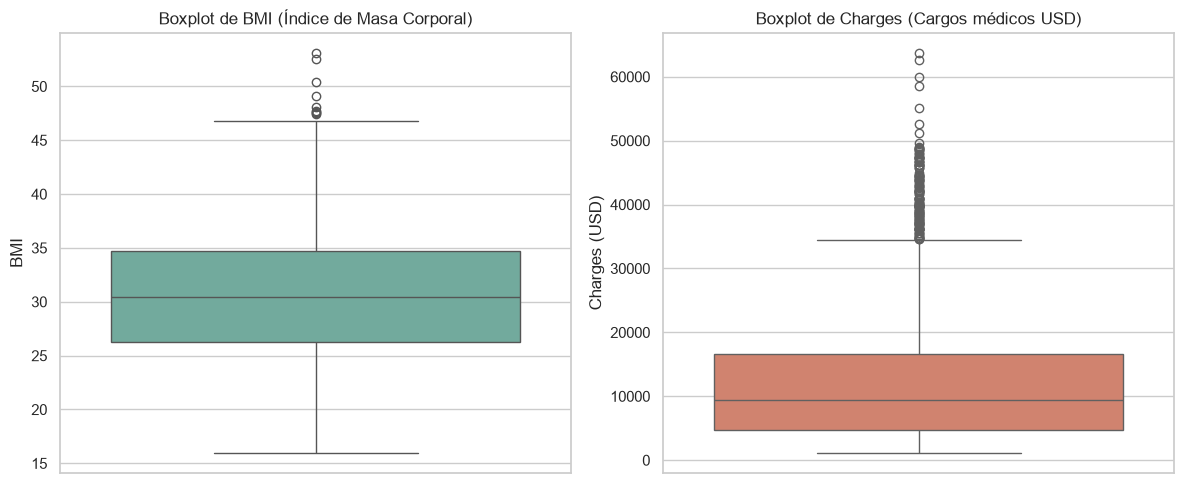

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(y=df["bmi"], ax=axes[0], color="#69b3a2")
axes[0].set_title("Boxplot de BMI (Índice de Masa Corporal)")
axes[0].set_ylabel("BMI")

sns.boxplot(y=df["charges"], ax=axes[1], color="#e07a5f")
axes[1].set_title("Boxplot de Charges (Cargos médicos USD)")
axes[1].set_ylabel("Charges (USD)")

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/01_boxplots_outliers.png", dpi=150, bbox_inches="tight")
plt.show()

Conteo de valores atípicos en `bmi` y `charges` según el criterio del rango
intercuartílico (IQR).

In [3]:
# Conteo de outliers por el criterio del rango intercuartilico (IQR)
def contar_outliers(serie):
    q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((serie < lim_inf) | (serie > lim_sup)).sum()

for col in ["bmi", "charges"]:
    print(f"Outliers en '{col}' (criterio IQR): {contar_outliers(df[col])}")

Outliers en 'bmi' (criterio IQR): 9
Outliers en 'charges' (criterio IQR): 139


## 2. Distribución de variables numéricas

Histogramas con curva de densidad (KDE) de las variables numéricas `age`, `bmi`,
`children` y `charges`. El título de cada uno muestra su coeficiente de asimetría (skew).

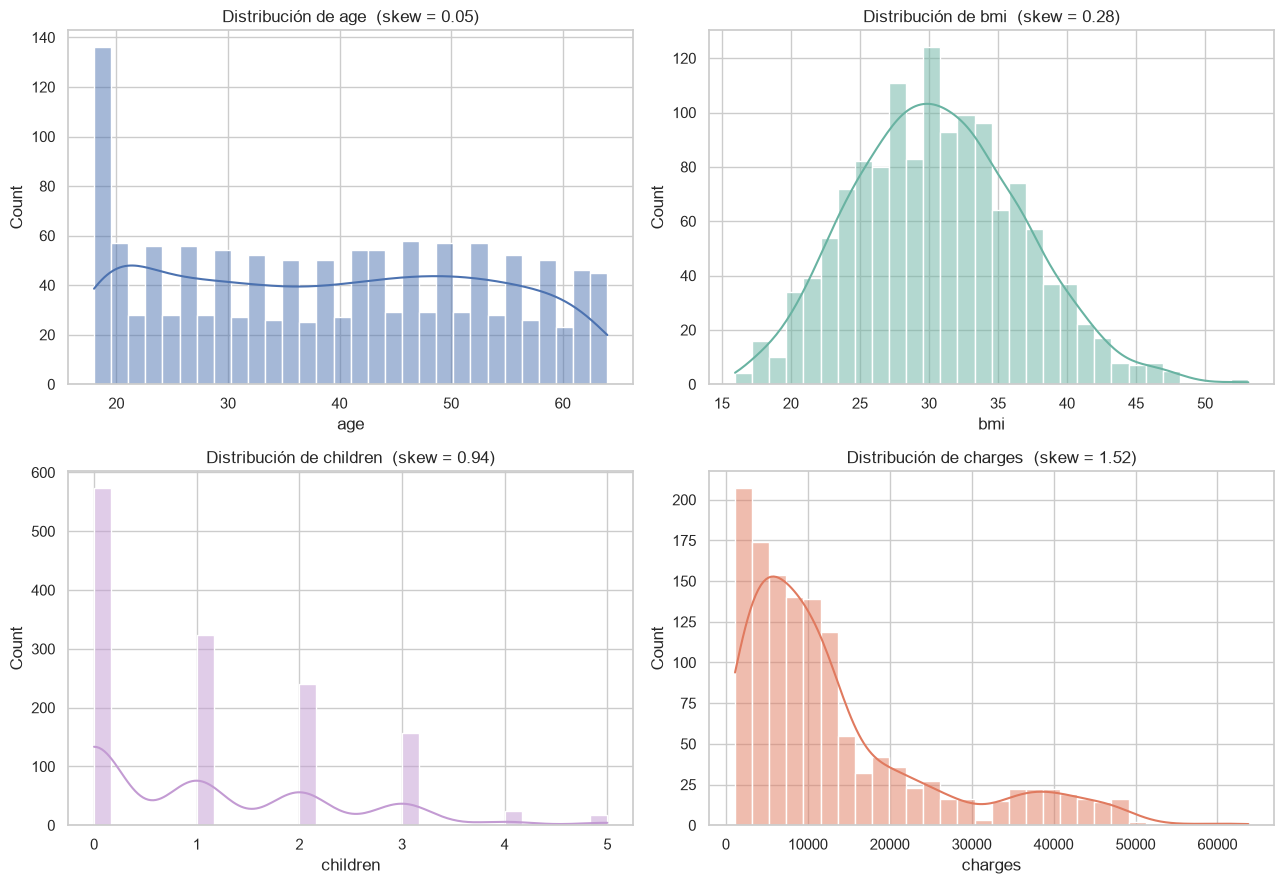

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
num_cols = ["age", "bmi", "children", "charges"]
colores = ["#4c72b0", "#69b3a2", "#c39bd3", "#e07a5f"]

for ax, col, c in zip(axes.ravel(), num_cols, colores):
    sns.histplot(df[col], kde=True, ax=ax, color=c, bins=30)
    ax.set_title(f"Distribución de {col}  (skew = {df[col].skew():.2f})")
    ax.set_xlabel(col)

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/02_histogramas_numericas.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Distribución de variables categóricas

Gráficas de barras con el conteo de registros por categoría en `sex`, `smoker` y
`region`.

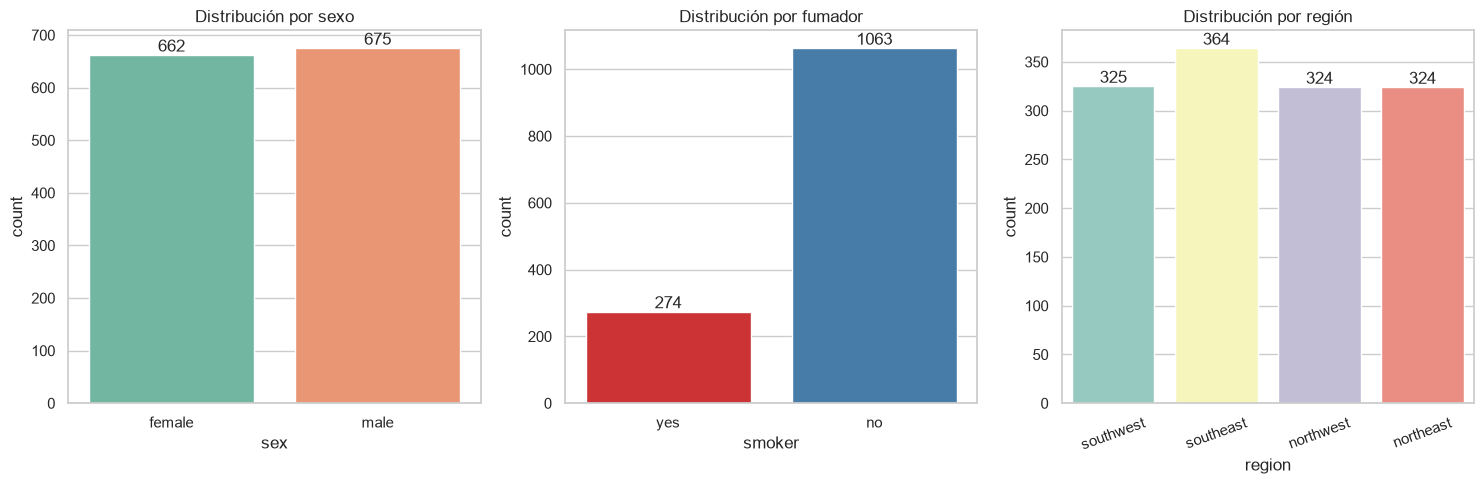

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.countplot(x="sex", data=df, ax=axes[0], hue="sex", palette="Set2", legend=False)
axes[0].set_title("Distribución por sexo")

sns.countplot(x="smoker", data=df, ax=axes[1], hue="smoker", palette="Set1", legend=False)
axes[1].set_title("Distribución por fumador")

sns.countplot(x="region", data=df, ax=axes[2], hue="region", palette="Set3", legend=False)
axes[2].set_title("Distribución por región")
axes[2].tick_params(axis="x", rotation=20)

# Etiquetas con el conteo encima de cada barra
for ax in axes:
    for cont in ax.containers:
        ax.bar_label(cont)

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/03_countplots_categoricas.png", dpi=150, bbox_inches="tight")
plt.show()

Conteo exacto de registros por categoría.

In [6]:
for col in ["sex", "smoker", "region"]:
    print(f"--- {col} ---")
    print(df[col].value_counts(), "\n")

--- sex ---
sex
male      675
female    662
Name: count, dtype: int64 

--- smoker ---
smoker
no     1063
yes     274
Name: count, dtype: int64 

--- region ---
region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64 



## 4. Relación entre variables clave

Gráficas de dispersión de `age` y `bmi` contra `charges`, coloreadas por `smoker`.

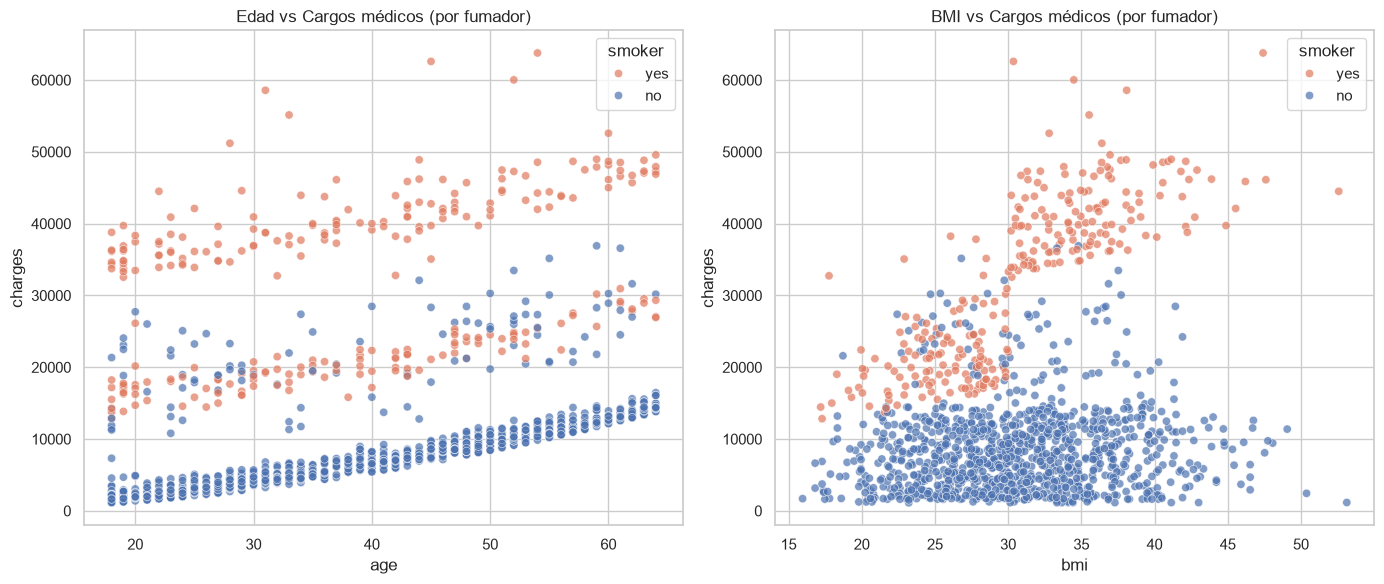

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(data=df, x="age", y="charges", hue="smoker",
                palette={"yes": "#e07a5f", "no": "#4c72b0"}, alpha=0.7, ax=axes[0])
axes[0].set_title("Edad vs Cargos médicos (por fumador)")

sns.scatterplot(data=df, x="bmi", y="charges", hue="smoker",
                palette={"yes": "#e07a5f", "no": "#4c72b0"}, alpha=0.7, ax=axes[1])
axes[1].set_title("BMI vs Cargos médicos (por fumador)")

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/04_scatter_age_bmi_vs_charges.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Vistas complementarias

### 5.1 `charges` en escala logarítmica

Histograma de `charges` en su escala original comparado con su escala logarítmica.

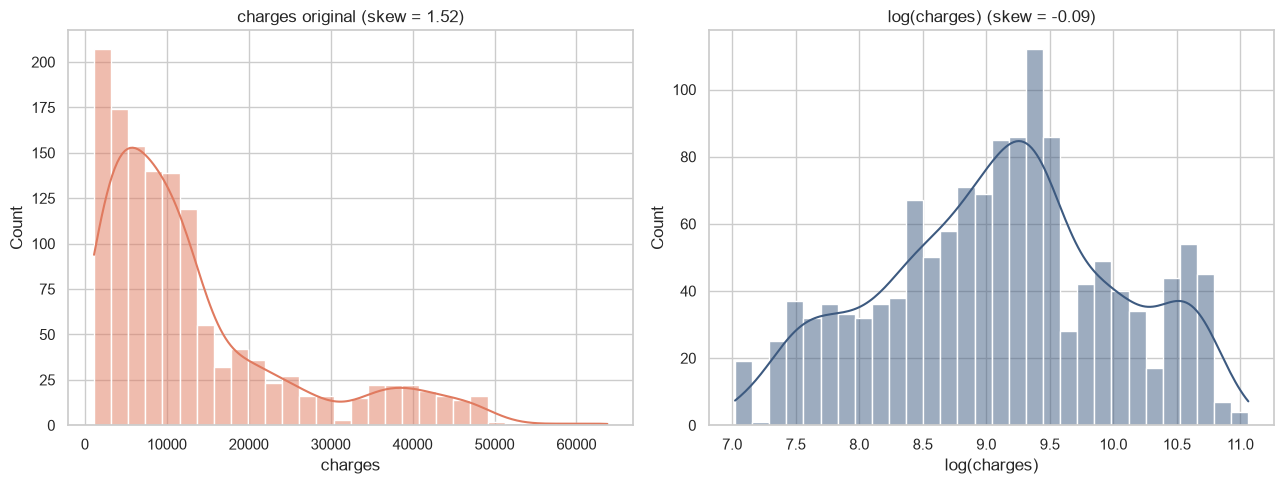

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(df["charges"], kde=True, ax=axes[0], color="#e07a5f", bins=30)
axes[0].set_title(f"charges original (skew = {df['charges'].skew():.2f})")

log_charges = np.log(df["charges"])
sns.histplot(log_charges, kde=True, ax=axes[1], color="#3d5a80", bins=30)
axes[1].set_title(f"log(charges) (skew = {log_charges.skew():.2f})")
axes[1].set_xlabel("log(charges)")

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/05_charges_log.png", dpi=150, bbox_inches="tight")
plt.show()

### 5.2 `charges` por grupo

Boxplots de `charges` separados por `smoker`, `sex` y `region`.

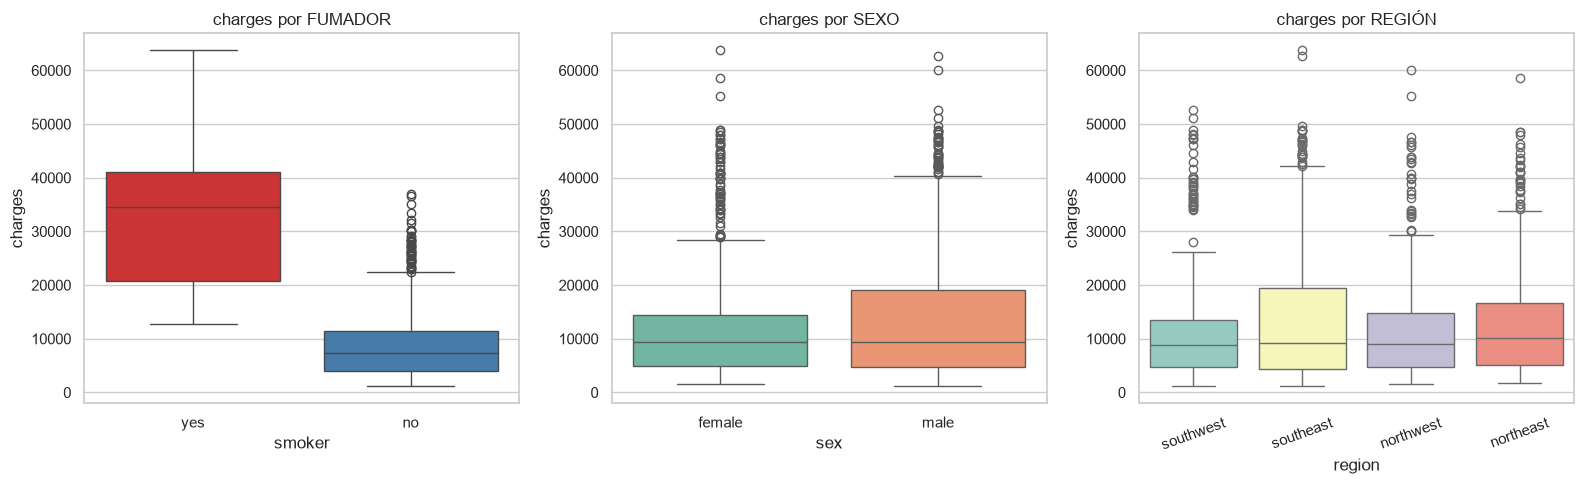

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(data=df, x="smoker", y="charges", ax=axes[0],
            hue="smoker", palette="Set1", legend=False)
axes[0].set_title("charges por FUMADOR")

sns.boxplot(data=df, x="sex", y="charges", ax=axes[1],
            hue="sex", palette="Set2", legend=False)
axes[1].set_title("charges por SEXO")

sns.boxplot(data=df, x="region", y="charges", ax=axes[2],
            hue="region", palette="Set3", legend=False)
axes[2].set_title("charges por REGIÓN")
axes[2].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/06_charges_por_grupo.png", dpi=150, bbox_inches="tight")
plt.show()

Gasto medio de `charges` por cada grupo (respaldo numérico de los boxplots anteriores).

In [10]:
# Gasto medio por grupo (respaldo numerico de los boxplots)
print("Gasto medio (charges) por grupo:\n")
print("Por fumador:\n", df.groupby("smoker")["charges"].mean().round(0), "\n")
print("Por sexo:\n", df.groupby("sex")["charges"].mean().round(0), "\n")
print("Por region:\n", df.groupby("region")["charges"].mean().round(0))

Gasto medio (charges) por grupo:

Por fumador:
 smoker
no      8441.0
yes    32050.0
Name: charges, dtype: float64 

Por sexo:
 sex
female    12570.0
male      13975.0
Name: charges, dtype: float64 

Por region:
 region
northeast    13406.0
northwest    12451.0
southeast    14735.0
southwest    12347.0
Name: charges, dtype: float64
